In [129]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score,mean_squared_error
import joblib
%matplotlib inline
sns.set_theme(style="whitegrid")

df_train = pd.read_csv(r"G:\family_file\legon5\MO\mostafa_saad_task\4-vid_28_project\code+data\train.csv")
df_val = pd.read_csv(r"G:\family_file\legon5\MO\mostafa_saad_task\4-vid_28_project\code+data\val.csv")

In [130]:
df_train.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


In [131]:
df_val.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2542907,1,2016-01-10 16:01:46,1,-74.013916,40.713444,-73.993858,40.752510,N,1249
1,id1709406,1,2016-06-23 18:41:05,1,-74.005440,40.727306,-73.983063,40.734715,N,817
2,id0983698,1,2016-05-14 21:25:34,1,-73.987587,40.749863,-73.986809,40.757549,N,366
3,id3045153,2,2016-05-02 20:09:00,1,-73.973862,40.784153,-73.983025,40.774479,N,195
4,id2383875,1,2016-05-19 10:01:39,1,-73.999916,40.733101,-74.008331,40.734177,N,283


## Initial Data Exploration (EDA)

In [132]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  object 
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  object 
 3   passenger_count     1000000 non-null  int64  
 4   pickup_longitude    1000000 non-null  float64
 5   pickup_latitude     1000000 non-null  float64
 6   dropoff_longitude   1000000 non-null  float64
 7   dropoff_latitude    1000000 non-null  float64
 8   store_and_fwd_flag  1000000 non-null  object 
 9   trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 76.3+ MB


To determine the number of delivery companies and the number of trips for each company

vendor_id
2    534793
1    465207
Name: count, dtype: int64


C:\Users\moham\AppData\Local\Temp\ipykernel_7836\3752869391.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendor_counts.index, y=vendor_counts.values, palette='viridis')


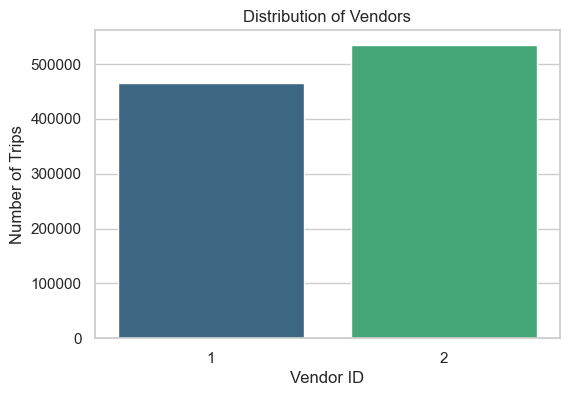

In [133]:
vendor_counts = df_train['vendor_id'].value_counts()

print(vendor_counts)
plt.figure(figsize=(6, 4))
sns.barplot(x=vendor_counts.index, y=vendor_counts.values, palette='viridis')
plt.title('Distribution of Vendors')
plt.xlabel('Vendor ID')
plt.ylabel('Number of Trips')
plt.show()

To calculate the number of passengers in each trip

In [134]:
passenger_freq = df_train['passenger_count'].value_counts().sort_index()

print(passenger_freq)

passenger_count
0        38
1    708628
2    143907
3     41012
4     19491
5     53635
6     33287
7         2
Name: count, dtype: int64


 To analyze the relationship between the number of passengers and trip duration

In [135]:
# Converted to minutes here for display purposes only to make the values easier to read
df_train['duration_min'] = df_train['trip_duration'] / 60
passenger_duration_mean = df_train.groupby('passenger_count')['duration_min'].mean()
print("--- Average Trip Duration (in Minutes) by Passenger Count ---")
print(passenger_duration_mean)

--- Average Trip Duration (in Minutes) by Passenger Count ---
passenger_count
0     3.079825
1    15.417061
2    16.609128
3    17.171244
4    17.563101
5    17.872759
6    17.855198
7     0.333333
Name: duration_min, dtype: float64


 Drop rows where passenger_count is zero

In [136]:
df_train = df_train[df_train['passenger_count'] >= 1]
df_val   = df_val[df_val['passenger_count'] >= 1]

print (df_train['passenger_count'].value_counts().sort_index())
print (df_val['passenger_count'].value_counts().sort_index())

passenger_count
1    708628
2    143907
3     41012
4     19491
5     53635
6     33287
7         2
Name: count, dtype: int64
passenger_count
1    162574
2     33166
3      9458
4      4441
5     12162
6      7503
7         1
8         1
Name: count, dtype: int64


trip duration describe

In [137]:
## time in seconds 
df_train['trip_duration'].describe()

count    9.999620e+05
mean     9.549142e+02
std      3.882140e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.074000e+03
max      2.227612e+06
Name: trip_duration, dtype: float64

(Data Type Conversion)

In [138]:
# Convert the time column in both datasets/groups
df_train['pickup_datetime'] = pd.to_datetime(df_train['pickup_datetime'])
df_val  ['pickup_datetime'] = pd.to_datetime(df_val['pickup_datetime'])

# Convert the flag column to numeric values
df_train['store_and_fwd_flag'] = df_train['store_and_fwd_flag'].map({'N':0, 'Y':1})
df_val  ['store_and_fwd_flag'] = df_val['store_and_fwd_flag'].map({'N':0, 'Y':1})

# We will drop this feature if the value counts are not balanced / consistent

In [139]:
df_train['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
0    994407
1      5555
Name: count, dtype: int64

 Remove trips with durations less than one minute or longer than 2 hour (data cleaning)

In [140]:
# Clean the training dataset
df_train = df_train[(df_train['trip_duration']>= 60) & (df_train['trip_duration']<= 7200)] 
# Clean the validation dataset
df_val = df_val[(df_val['trip_duration']>=60) & (df_val["trip_duration"]<= 7200)]
# Apply log transformation to the target variable to achieve a more normal distribution
y_train_log = np.log1p(df_train['trip_duration'])
y_val_log = np.log10(df_val['trip_duration'])
print(f"Records removed! Remaining number of rows in Train: {len(df_train)}")

Records removed! Remaining number of rows in Train: 992634


## featurs engineering 

##-------------------11111111-----------------##
## Feature to calculate the distance between pickup and drop-off points
## by converting coordinates to radians and returning the distance in kilometers
## Since we travel on the Earth's surface (not through underground tunnels),
## this line uses the arctan2 function to convert chord distance into arc distance

In [141]:
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(delta_lambda/2)**2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1-a))


# Apply the function to calculate the distance in kilometers


In [142]:
df_train['distance_km'] = haversine_distance(df_train['pickup_latitude'], df_train['pickup_longitude'], 
                                             df_train['dropoff_latitude'], df_train['dropoff_longitude'])

df_val['distance_km'] = haversine_distance(df_val['pickup_latitude'], df_val['pickup_longitude'], 
                                           df_val['dropoff_latitude'], df_val['dropoff_longitude'])


print("--- Distance Statistics (km) ---")
print(df_train['distance_km'].describe())


--- Distance Statistics (km) ---
count    992634.000000
mean          3.455607
std           4.415993
min           0.000000
25%           1.244384
50%           2.103812
75%           3.887881
max        1240.908677
Name: distance_km, dtype: float64


 Remove trips shorter than 0.1 km

In [143]:
print(f"Deleted successfully! Remaining number of records in Train: {len(df_train)}")
## Remove trips with zero distance (data cleaning)
df_train = df_train[df_train['distance_km'] >= 0.1]
df_val   = df_val[df_val['distance_km']>= 0.1]

print(f"Deleted successfully! Remaining number of records in Train: {len(df_train)}")

Deleted successfully! Remaining number of records in Train: 992634
Deleted successfully! Remaining number of records in Train: 987367


feature 2

##-------------------22222222-----------------##
# Extract hour and day of the week
# 0 = Monday, 6 = Sunday


In [144]:
df_train['hour'] = df_train['pickup_datetime'].dt.hour
df_train['day_of_week'] = df_train['pickup_datetime'].dt.weekday

df_val['hour'] = df_val['pickup_datetime'].dt.hour
df_val['day_of_week'] = df_val['pickup_datetime'].dt.weekday


feature 3 

##-------------------33333333-----------------##
## Identify the busiest hours

In [145]:
hourly_trips_sorted = df_train['hour'].value_counts().sort_values()
print(hourly_trips_sorted)

## From 18 to 22 are the peak (busiest) hours
df_train['is_peak_hour'] = df_train['hour'].apply(lambda x: 1 if 18 <= x <= 22 else 0)
df_val['is_peak_hour']   = df_val['hour'].apply(lambda x: 1 if 18 <= x <= 22 else 0)


hour
5     10023
4     10572
3     14079
2     18801
6     22521
1     26288
0     35877
7     37574
16    43629
10    44423
8     45449
9     46074
11    46428
23    47417
13    48420
12    48517
15    48609
14    50216
17    51586
22    54390
20    57001
21    57129
19    61012
18    61332
Name: count, dtype: int64


feature 4

##-------------------44444444-----------------##
## Identify the busiest days (4 and 5 represent Friday and Saturday)

In [146]:
peak_days_trips = df_train['day_of_week'].value_counts().sort_values()
print(peak_days_trips)

## Define weekend (busy days) indicator
df_train['is_busy_weekend'] = df_train['day_of_week'].apply(lambda x: 1 if x in [4, 5] else 0)
df_val['is_busy_weekend']   = df_val['day_of_week'].apply(lambda x: 1 if x in [4, 5] else 0)


day_of_week
0    126897
6    132451
1    137087
2    142471
3    148091
5    149499
4    150871
Name: count, dtype: int64


feature 5

##-------------------55555555-----------------##
## Identify holidays

In [147]:
import holidays

# Define US holidays (NY state is specified for higher accuracy)
us_holidays = holidays.US(state='NY')

# Apply the function to mark holidays
df_train['is_holiday'] = df_train['pickup_datetime'].apply(lambda x: 1 if x in us_holidays else 0)
df_val['is_holiday']   = df_val['pickup_datetime'].apply(lambda x: 1 if x in us_holidays else 0)


feature 6

##-------------------66666666-----------------## 
## split the trips based on the number of passengers

In [148]:
df_train['duration_min'] = df_train['trip_duration'] / 60
passenger_duration_mean = df_train.groupby('passenger_count')['duration_min'].mean()
print("--- Average Trip Duration (Minutes) by Passenger Count ---")
print(passenger_duration_mean)

## single
df_train['is_single_passenger'] = (df_train['passenger_count'] ==1).astype(int)
df_val['is_single_passenger'] = (df_val['passenger_count'] == 1).astype(int)
## larg group
df_train['is_large_group'] = (df_train['passenger_count'] >=3).astype(int)
df_val['is_large_group'] = (df_val['passenger_count'] >= 3).astype(int)

--- Average Trip Duration (Minutes) by Passenger Count ---
passenger_count
1    13.819071
2    14.698740
3    14.469115
4    14.849812
5    14.110880
6    13.994662
Name: duration_min, dtype: float64


feature 7

##-------------------77777777-----------------##
## The most important feature to estimate real traffic congestion
## by calculating the average speed (km per hour) and identifying hours below the average


# --- IMPORTANT: Feature Engineering & Leakage Prevention ---
# We are calculating the 'avg_hourly_speed' as a historical reference from the TRAINING set only.
# This represents the "City's typical traffic patterns" at specific hours.
# To prevent Data Leakage: 
# 1. We derive the mapping exclusively from the training data.
# 2. We apply (map) this historical knowledge to the validation set.
# This ensures the model uses past historical patterns to predict future trip durations 
# without knowing the actual speed of the current trip in the validation set.

In [149]:
df_train['temp_speed'] = df_train['distance_km'] / (df_train['trip_duration'] / 60)

hourly_speed = df_train.groupby('hour')['temp_speed'].mean()

# Now map the hourly average speed to both Train and Validation sets
df_train['avg_hourly_speed'] = df_train['hour'].map(hourly_speed)
df_val['avg_hourly_speed']   = df_val['hour'].map(hourly_speed)

# Drop the temporary column
df_train.drop(columns=['temp_speed'], inplace=True)

# Consider an hour as congested if its speed is below the city-wide average speed
city_avg_speed = df_train['avg_hourly_speed'].mean()

df_train['is_traffic_jam'] = df_train['avg_hourly_speed'].apply(lambda x: 1 if x < city_avg_speed else 0)
df_val['is_traffic_jam']   = df_val['avg_hourly_speed'].apply(lambda x: 1 if x < city_avg_speed else 0)


# Create a table containing each hour and its corresponding average speed
# We will use the data previously calculated in 'hourly_speed'

In [150]:
traffic_summary = hourly_speed.reset_index()
traffic_summary.columns = ['hour', 'avg_speed_km_h']

# Add a status column to identify congestion (speed lower than city average)
traffic_summary['status'] = traffic_summary['avg_speed_km_h'].apply(
    lambda x: 'slow ' if x < city_avg_speed else ' (Fast) '
)

# Display the table sorted by hours (from 0 to 23)
print(f"City Average Speed: {city_avg_speed:.2f} km/h\n")
print(traffic_summary.to_string(index=False))

City Average Speed: 0.24 km/h

 hour  avg_speed_km_h   status
    0        0.296092  (Fast) 
    1        0.308763  (Fast) 
    2        0.316502  (Fast) 
    3        0.334560  (Fast) 
    4        0.371618  (Fast) 
    5        0.408227  (Fast) 
    6        0.343834  (Fast) 
    7        0.264038  (Fast) 
    8        0.216625    slow 
    9        0.211456    slow 
   10        0.213495    slow 
   11        0.208643    slow 
   12        0.205583    slow 
   13        0.208803    slow 
   14        0.204654    slow 
   15        0.202573    slow 
   16        0.210597    slow 
   17        0.209100    slow 
   18        0.213919    slow 
   19        0.227361    slow 
   20        0.255124  (Fast) 
   21        0.265104  (Fast) 
   22        0.268193  (Fast) 
   23        0.283828  (Fast) 


In [151]:
pd.set_option('display.max_columns', None)

df_train.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,duration_min,distance_km,hour,day_of_week,is_peak_hour,is_busy_weekend,is_holiday,is_single_passenger,is_large_group,avg_hourly_speed,is_traffic_jam
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,0,1040,17.333333,2.763050,7,2,0,0,0,1,0,0.264038,0
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,0,827,13.783333,1.959178,12,6,0,0,0,1,0,0.205583,1
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,0,614,10.233333,1.404772,2,6,0,0,0,0,1,0.316502,0
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,0,867,14.450000,1.978660,17,3,0,0,0,0,0,0.209100,1
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,0,4967,82.783333,20.837745,17,3,0,0,0,0,1,0.209100,1


## Model Training & Evaluation

 Training completed successfully!
 RMSE: 433.99 seconds
 Average Error per Trip (MAE): 290.64 seconds
 Error in minutes: 4.84 min


C:\Users\moham\AppData\Local\Temp\ipykernel_7836\871466379.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Dataset', y='RMSE', data=errors, palette='Set2')


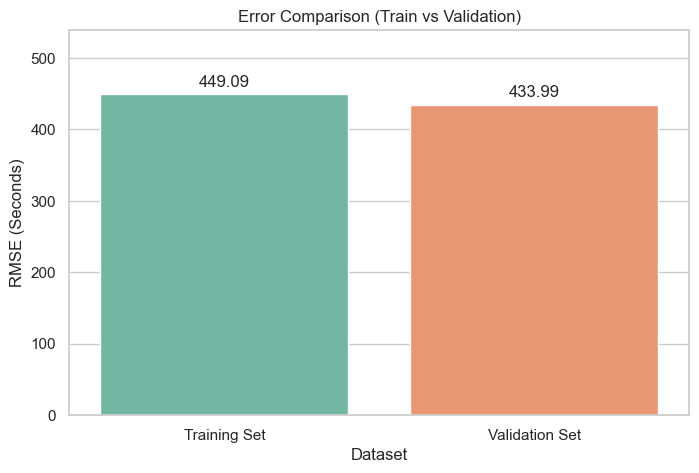

In [152]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error # الإضافة الوحيدة في المكتبات

# 1. Define features (ensure 'is_large_group' spelling matches your dataset)
features = [
    'vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'distance_km', 'hour', 
    'day_of_week', 'is_peak_hour', 'is_busy_weekend', 'is_holiday',
    'is_single_passenger', 'is_large_group', 'avg_hourly_speed', 'is_traffic_jam'
]

# 2. Prepare matrices for training and validation
X_train = df_train[features]
y_train = df_train['trip_duration']
X_val = df_val[features]
y_val = df_val['trip_duration']

# 3. Feature Scaling (Crucial step for Ridge Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 4. Model Training
model = Ridge(alpha=1)
model.fit(X_train_scaled, y_train)

# 5. Prediction and Evaluation
y_pred = model.predict(X_val_scaled)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
# حساب متوسط الخطأ المطلق لكل رحلة (الإضافة المطلوبة)
mae = mean_absolute_error(y_val, y_pred) 

print(f" Training completed successfully!")
print(f" RMSE: {rmse:.2f} seconds")
print(f" Average Error per Trip (MAE): {mae:.2f} seconds") # السطر الجديد
print(f" Error in minutes: {mae/60:.2f} min") # تحويل الـ MAE لدقائق أوضح

# Calculate prediction and error for the Training set
y_train_pred = model.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Prepare data for plotting
errors = pd.DataFrame({
    'Dataset': ['Training Set', 'Validation Set'],
    'RMSE': [train_rmse, rmse] 
})

# Visualization
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Dataset', y='RMSE', data=errors, palette='Set2')
plt.title('Error Comparison (Train vs Validation)')
plt.ylabel('RMSE (Seconds)')

# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.ylim(0, max(train_rmse, rmse) * 1.2) 
plt.show()

feature weights

C:\Users\moham\AppData\Local\Temp\ipykernel_7836\2599441453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=importance, palette='viridis')


                Feature      Weight
6           distance_km  425.013076
4     dropoff_longitude   58.957243
10      is_busy_weekend   15.427509
15       is_traffic_jam   13.305508
7                  hour   12.662486
2      pickup_longitude    7.681262
13       is_large_group    5.654476
0             vendor_id   -0.987459
1       passenger_count  -12.932628
12  is_single_passenger  -16.905609
11           is_holiday  -21.494420
9          is_peak_hour  -23.002206
8           day_of_week  -29.610995
5      dropoff_latitude  -48.801114
3       pickup_latitude  -57.236359
14     avg_hourly_speed  -93.332906


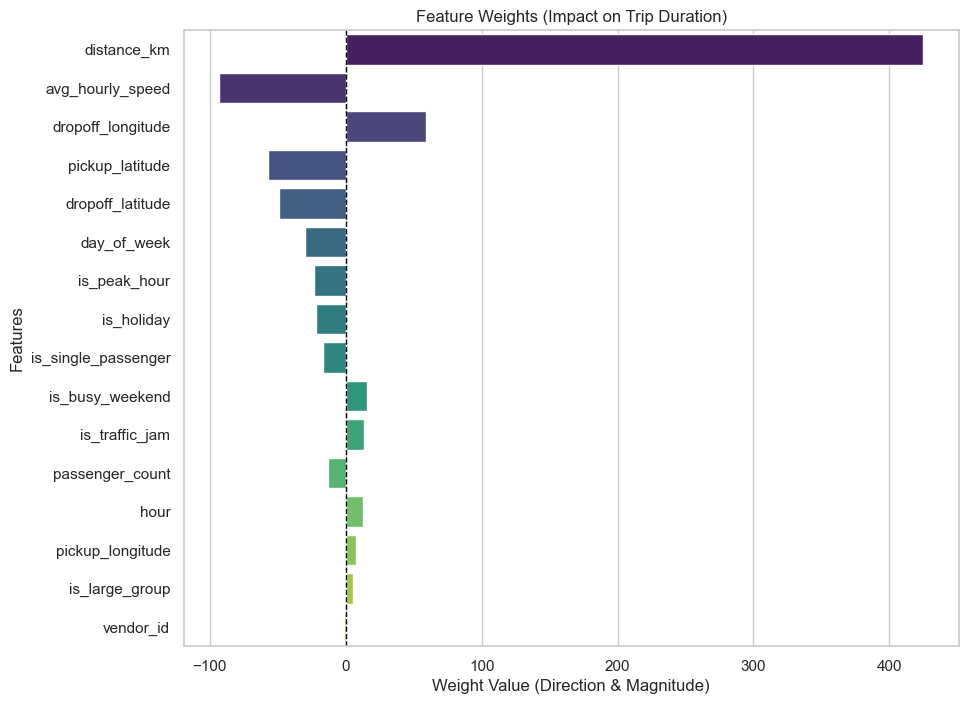

In [153]:
# Display feature importance after scaling
importance = pd.DataFrame({'Feature': features, 'Weight': model.coef_})
print(importance.sort_values(by='Weight', ascending=False))

# Prepare data for visualization
importance = pd.DataFrame({'Feature': features, 'Weight': model.coef_})
importance['Abs_Weight'] = importance['Weight'].abs() # Get absolute value for ranking magnitude
importance = importance.sort_values(by='Abs_Weight', ascending=False)

# Visualization
plt.figure(figsize=(10, 8))
sns.barplot(x='Weight', y='Feature', data=importance, palette='viridis')
plt.title('Feature Weights (Impact on Trip Duration)')
plt.xlabel('Weight Value (Direction & Magnitude)')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Zero line for reference
plt.show()

## Summary: The model successfully predicts trip durations by leveraging geographical data and historical traffic patterns. The inclusion of avg_hourly_speed & distance_km was the most significant features in improving prediction accuracy